In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici
from scipy.interpolate import interp1d
from classy import Class
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [46]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':1,
'background_verbose':3,
'output':'mTk, vTk, dTk, mPk',
'P_k_max_1/Mpc':10,
'z_max_pk':1000,
'format':'class',
# 'gauge':'newtonian',
}
# ChatGPT says that 1 eV = 4.827e19 invMpc
chiCDM = Class()
chiCDM.set(common_settings)

m_ev = 1.e-27
fx = 0.1
chiCDM.set({
    'omega_cdm': 0.12,
    'scf_potential': 'axion',
    'n_axion': 1,
    'f_axion': 0.4,  # in units of mpl
    'Omega_scf' : ((fx/(1-fx))*(0.12+0.02238))/h/h,
    'm_axion': m_ev * _ev_to_HO_,  # in units of H0
    'tol_shooting_deltax': 1e-4,
    'tol_shooting_deltaF': 1e-4,
    'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
    'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
    'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
    'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
    'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
    'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
    'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
    'scf_has_perturbations': 'yes',  # for pedagogical purposes only
    'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
    'use_delta_scf_over_1plusw': 'no',
    'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
    'evolver': 0,
    'background_verbose':2
})

chiCDM.compute()

Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368998 Gyr
 -> conformal age = 13577.281529 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3781.414959
    corresponding to conformal time = 102.229871 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega = 0.12           
-> Axion DM                       Omega = 0.0344048       , omega = 0.01582        
 ---> Relativistic Species 
-> Photons                        Omega = 5.37815e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.71799e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.655855        , omega = 0.3

In [47]:
chi_tk_k = chiCDM.get_transfer(z=0.5)
print(chi_tk_k.keys())
chibck = chiCDM.get_background() # load background table
f_of_z = interp1d(chibck['z'],chibck['gr.fac. f'])
Ha_of_z = interp1d(chibck['z'],chibck['H [1/Mpc]']/(1+chibck['z']))
Ha_0p5=Ha_of_z(0.5)

f_0p5=f_of_z(0.5)
print(chibck.keys())
# H0p5 = Ha_chi_int(0.666)/0.666


dict_keys(['k (h/Mpc)', 'd_g', 'd_b', 'd_cdm', 'd_ur', 'd_scf', 'delta_phi_scf', 'delta_phi_over_phi_scf', 'delta_phi_prime_scf', 'd_tot', 'phi', 'psi', 't_g', 't_b', 't_ur', 't_scf', 't_tot'])
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)Omega_scf', '(.)p_scf', '(.)p_prime_scf', '(.)w_scf', '(.)dw_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


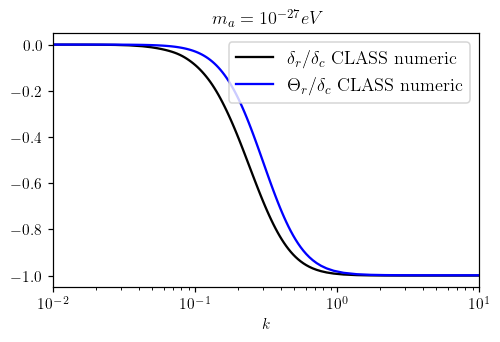

In [68]:
kEval=chi_tk_k['k (h/Mpc)']
d_ax_k=-chi_tk_k['d_scf']
d_cdm_k=-chi_tk_k['d_cdm']

T_rel =chi_tk_k['t_scf']/Ha_0p5/f_0p5

plt.figure(figsize=(5,3), dpi=110)
# plt.plot(kEval, d_ax_k/ d_cdm_k,'k',label=r'$\frac{\delta_a}{\delta_c}(k)$ CLASS numeric')
plt.plot(kEval, (d_ax_k-d_cdm_k)/ d_cdm_k,'k',label=r'$\delta_r/\delta_c$ CLASS numeric')

plt.plot(kEval, T_rel/d_cdm_k,'b',label=r'$\Theta_r/\delta_c$ CLASS numeric')

plt.xscale('log')
plt.xlabel(r'$k$')
plt.legend( fontsize=12)
plt.xlim([1.e-2,1.e1])
plt.title(r'$m_a = 10^{-27}eV$')
plt.show()

In [60]:
np.savetxt('/home/fverdian/class/soundspeed-scripts/figure/transfers_ULAm27.txt', np.column_stack((kEval, d_cdm_k, d_ax_k, T_rel)), header='k (h/Mpc), d_cdm, d_a, T_r')